# Customer Segmentation Analysis using K-Means Clustering

## Objective
The objective of this project is to segment customers into different groups based on their purchasing behaviour using RFM(Recency,Frequency , Monetary) analysis and K-Means clustering.These customer segments help businesses create targeted marketing strategies and improve customer retention.

### Tools & Libraries
-Python
-Pandas
-Numpy
-Matplotlib
-Seaborn
-Scikit Learn

#### Dataset
Online Retail Dataset

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# Load Dataset
Load the online Retail dataset into a pandas DataFrame

In [52]:
df=pd.read_csv("data.csv",encoding='ISO-8859-1')

In [53]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


# Observation
The dataset contains customer purchase transactions including Invoice Number,Product Description,Quantity,Unit Price,Customer ID,Invoice Date and Country.

In [54]:
df.shape

(541909, 8)

In [55]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [56]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


# Observation
The dataset contains numerical and categorical variables.Invoice Date is currently stored as an object and needs conversion into datetime format.

In [57]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


# Missing Values

In [58]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

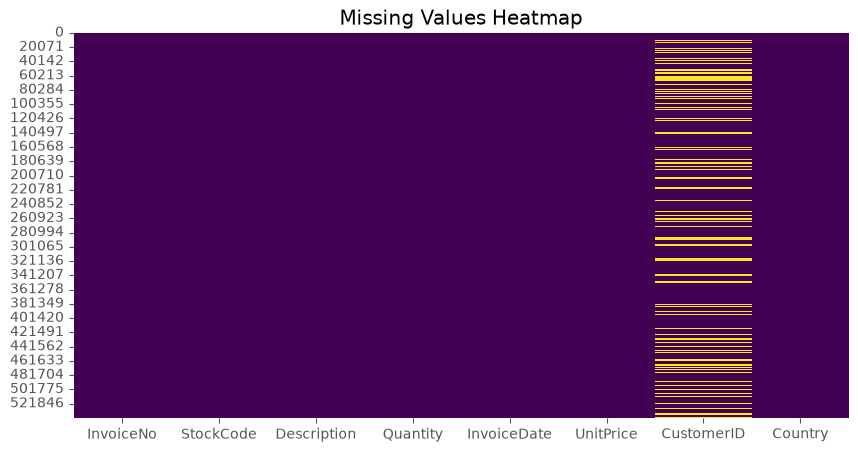

In [59]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(),cbar=False,cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

# Observation 
Customer ID and Description contain missing values.These missing values should be handled before performing clustering

In [60]:
df=df.dropna()

In [61]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

# Observation 
After removing missing values,the dataset contain complete records suitable for analysis.

In [62]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])

In [63]:
df.dtypes

InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

In [64]:
df['TotalPrice']=df['Quantity']*df['UnitPrice']

In [65]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


# Observation
A new feature called TotalPrice has been created.It represents the total amount spent on each transaction.

# RFM Analysis
RFM stands for:
    **Recency**-> Number of days since the customer's last purchase.
    **Frequency**-> Number of purchases made by the customer.
    **Monetary**-> Total amount spent by the customer.
    These three features are used to segment customers.

In [66]:
# Find the latest purchase date
snapshot_date=df['InvoiceDate'].max() + pd.Timedelta(days=1)
snapshot_date

Timestamp('2011-12-10 12:50:00')

In [67]:
# Create RFM Table
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm=df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x :
        (snapshot_date - x.max()).days,'InvoiceNo':'nunique',
        'TotalPrice':'sum'})
rfm.columns=['Recency','Frequency','Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,2,0.00
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


### Observation
Each row now represents one customer with three important features:
-Recency
-Frequency
-Monetary value

In [68]:
rfm.describe()

,Recency,Frequency,Monetary
count,4372.000000,4372.000000,4372.000000
mean,92.047118,5.075480,1898.459701
std,100.765435,9.338754,8219.345141
min,1.000000,1.000000,-4287.630000
25%,17.000000,1.000000,293.362500
50%,50.000000,3.000000,648.075000
75%,143.000000,5.000000,1611.725000
max,374.000000,248.000000,279489.020000


### Observation
The descriptive statistics summarize customer purchasing behavior, including average recency,purchase frequency, and spending.

# Check Missing Values

In [69]:
rfm.isnull().sum()

Recency      0
Frequency    0
Monetary     0
dtype: int64

In [70]:
rfm.info()

<class 'pandas.DataFrame'>
Index: 4372 entries, 12346.0 to 18287.0
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Recency    4372 non-null   int64  
 1   Frequency  4372 non-null   int64  
 2   Monetary   4372 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 136.6 KB


# Distribution of RFM Features

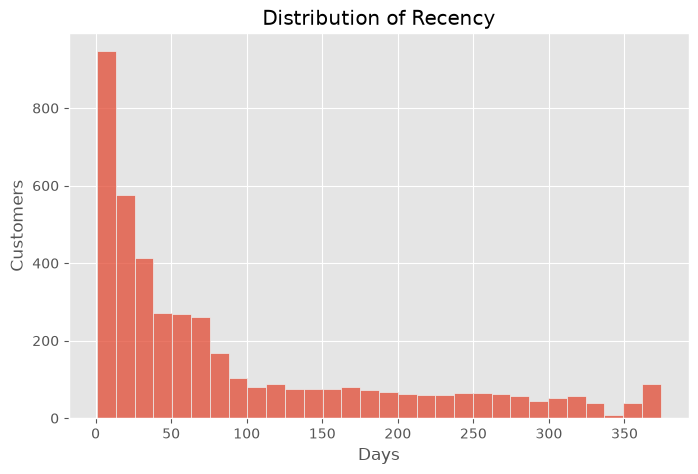

In [71]:
plt.figure(figsize=(8,5))
sns.histplot(rfm['Recency'],bins=30)
plt.title("Distribution of Recency")
plt.xlabel("Days")
plt.ylabel("Customers")
plt.show()

### Observation
Most customer purchased recently ,while a smaller number have not made purchases for a long time.

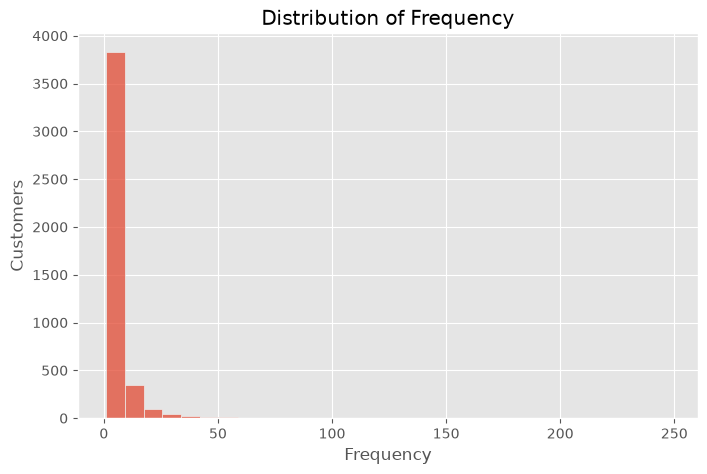

In [72]:
plt.figure(figsize=(8,5))
sns.histplot(rfm['Frequency'],bins=30)
plt.title("Distribution of Frequency")
plt.xlabel("Frequency")
plt.ylabel("Customers")
plt.show()

### Observation
Most customers make only a few purchases , while a few customers purchase very frequently.

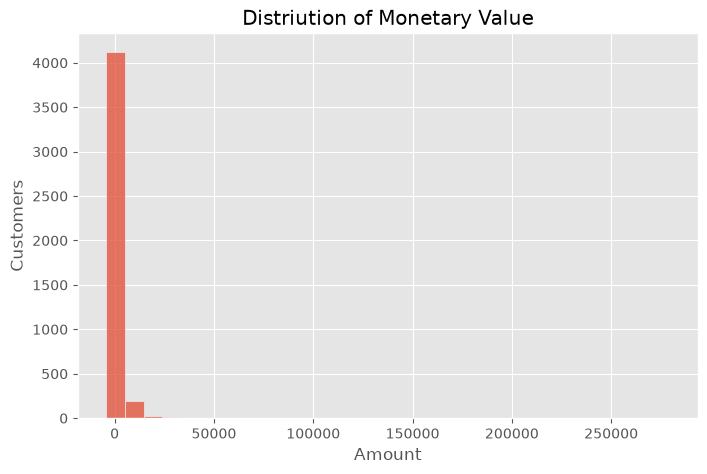

In [73]:
plt.figure(figsize=(8,5))
sns.histplot(rfm['Monetary'],bins=30)
plt.title("Distriution of Monetary Value")
plt.xlabel("Amount")
plt.ylabel("Customers")
plt.show()

### Observation
Customer spending is right-skewed, indicating that a small number of customers contribute significantly to total revenue.

# Correlation Analysis

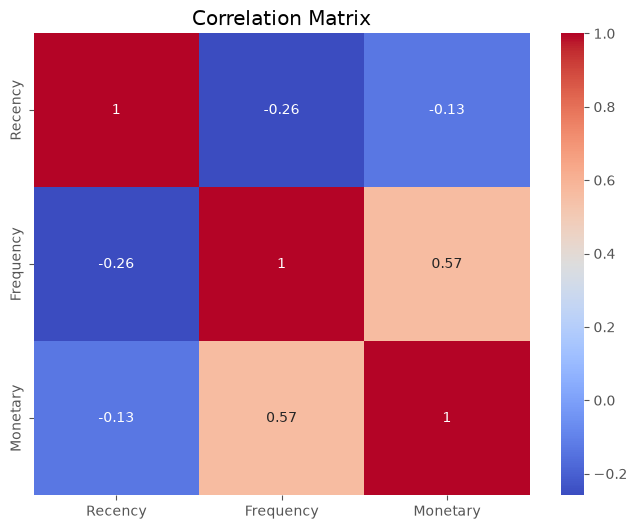

In [74]:
plt.figure(figsize=(8,6))
sns.heatmap(rfm.corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

### Observation
The correlation matrix shows the relationships between Recency,Frequency and Monetary values.Frequency and Monetary often have a positive correlation,indicating that frequent customers tend to spend more.

In [75]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,2,0.00
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


# Feature Scaling
Since Recency,Frequency and Monetary are measured on different scales, we standardize them before applying K-Means clustering.

In [76]:
scaler=StandardScaler()
rfm_scaled=scaler.fit_transform(rfm)

In [77]:
rfm_scaled

array([[ 2.32202285, -0.32936215, -0.23100099],
       [-0.89373323,  0.20610242,  0.29343167],
       [-0.1691956 , -0.11517632, -0.01231622],
       ...,
       [-0.83418219, -0.22226923, -0.20951263],
       [-0.87388289,  1.16993863,  0.02390005],
       [-0.48680114, -0.22226923, -0.00744423]], shape=(4372, 3))

### Observation
The RFM features have been standardize with a mean of 0 and a standard deviation of 1.This ensures that no single feature dominates the clustering process.

# Elbow Method
The Elbow Method helps determine the optimal number of clusters (K) for K-Means clustering.

In [78]:
wcss=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i,random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

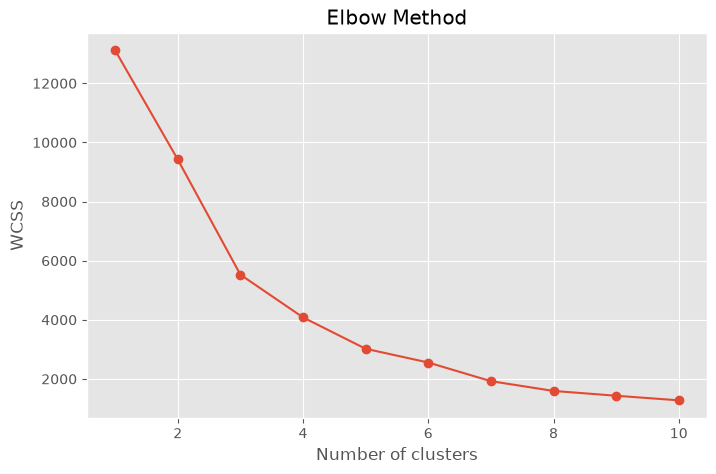

In [79]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11),wcss,marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

### Observation
The elbow point appears around **K=4**. Therefore , four customer segments are selected for K-Means clustering.

# Apply K-Means Clustering

In [80]:
kmeans=KMeans(n_clusters=4,random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [81]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,2,0.00,1
12347.0,2,7,4310.00,3
12348.0,75,4,1797.24,3
12349.0,19,1,1757.55,3
12350.0,310,1,334.40,1


### Observation
Each customer has been assigned to one of the four clusters based on their  purchasing behavior.

In [82]:
rfm['Cluster'].value_counts()

Cluster
3    3090
1    1077
0     194
2      11
Name: count, dtype: int64

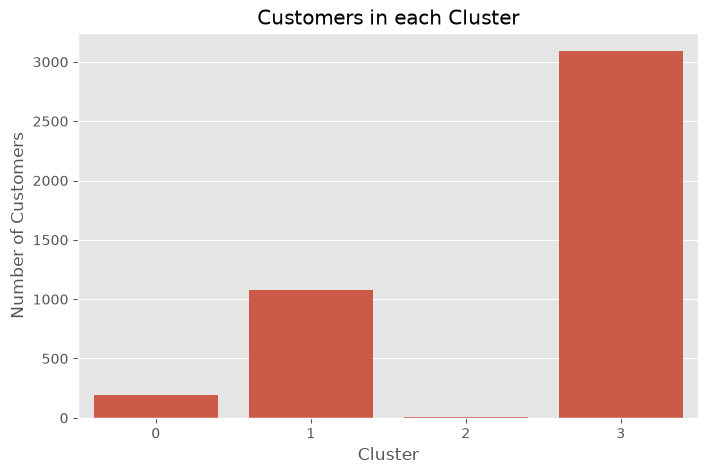

In [83]:
plt.figure(figsize=(8,5))
sns.countplot(x='Cluster',data=rfm)
plt.title("Customers in each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.show()

### Observation
The bar chart shows the number of customers in each cluster. This helps understand the distribution of customer groups.

# Cluster Summary

In [84]:
cluster_summary=rfm.groupby('Cluster').mean()
cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,10.752577,28.510309,12168.264691
1,248.927577,1.805942,455.110716
2,5.090909,109.909091,124312.306364
3,42.780906,4.370550,1320.981506


In [85]:
cluster_summary.style.background_gradient(cmap='Blues')

,Recency,Frequency,Monetary
Cluster,,,
0,10.752577,28.510309,12168.264691
1,248.927577,1.805942,455.110716
2,5.090909,109.909091,124312.306364
3,42.780906,4.370550,1320.981506


# Cluster Visualization
Visulizing customer clusters helps us understand how customers are grouped based on their purcahsing behavior.

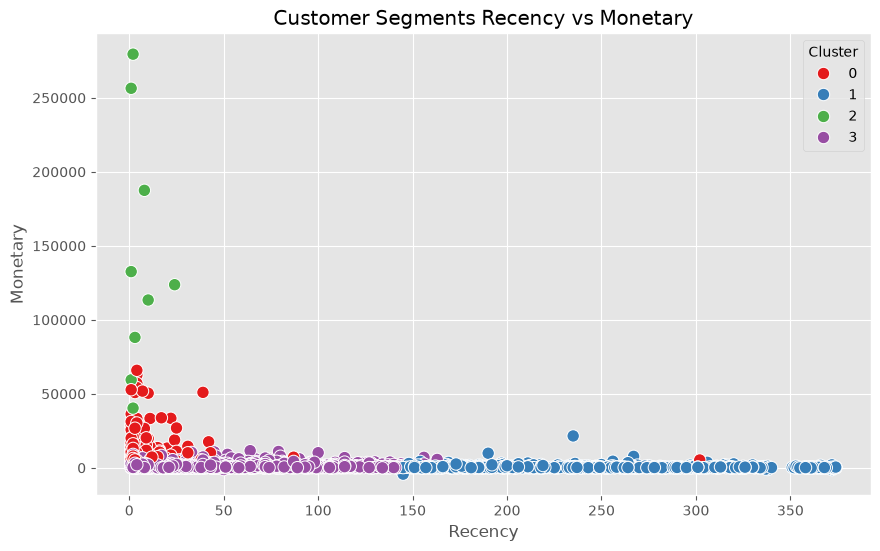

In [86]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='Recency',
    y='Monetary',
    hue='Cluster',
    data=rfm,
    palette='Set1',
    s=80
)
plt.title("Customer Segments Recency vs Monetary")
plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.show()

### Observation 
Customers are grouped based on how recently they purchased and how much they spent,High-value customers usually have lower recency and higher monetary values.

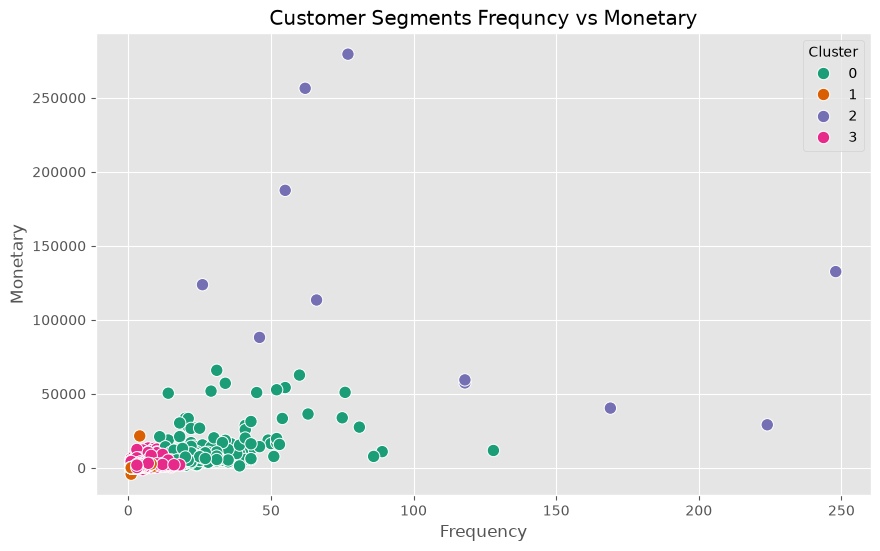

In [87]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    data=rfm,
    palette='Dark2',
    s=80
)
plt.title("Customer Segments Frequncy vs Monetary")
plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.show()

### Observation
Customers with higher purchase frequency generally spend more ,forming the most valuable customer segment.

# Cluster Profile

In [88]:
cluster_profile=rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()
cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,10.752577,28.510309,12168.264691
1,248.927577,1.805942,455.110716
2,5.090909,109.909091,124312.306364
3,42.780906,4.370550,1320.981506


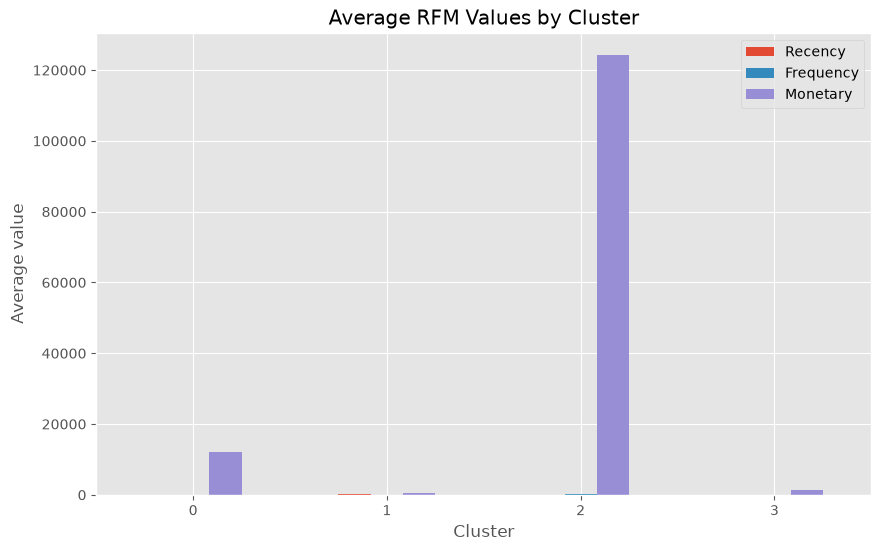

In [89]:
cluster_profile.plot(
    kind='bar',
    figsize=(10,6)
)
plt.title("Average RFM Values by Cluster")
plt.ylabel("Average value")
plt.xticks(rotation=0)
plt.show()

### Observation
Each cluster has unique purchasing behavior, some clusters contain loyal and high-spending customers, while others represent inactive or low-value customers.

# Marketing Recommendations

In [90]:
for cluster in sorted(rfm['Cluster'].unique()):
    print(f"/nCluster {cluster}")

/nCluster 0
/nCluster 1
/nCluster 2
/nCluster 3


### Marketing Insights
### Cluster 0
-High-value customers
-Offer loyalty rewards
-Provide exclusive discounts
### Cluster 1
-Regular customers
-REcommend related products
-Encourage repeat purchases
### Cluster 2
-At-risk customers
-Send personalized offers
-Provide limited-time discounts
### Cluster 3
-New or low-value customers
-Introduce welcome offers
-Increase engagement through email campaigns

## Conclusion
This project successfully segmented customers into different groups using RFM Analysis and K-Means Clustering
The analysis identified customers with different purchasing behavior, enabling businesses to:
-Improve customer retention 
-Increase sales
-Personalize marketing campaigns 
-Identify loyal customers
-Re-engage inactive customers
Customer segmentation helps organization make data-driven business decision and improve overall customer satisfaction.

In [91]:
rfm.to_csv("Customer_Segments.csv",index=True)
print("Customer segmentation results saved successfully")

Customer segmentation results saved successfully
